In [ ]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
import os
import sys
import urllib.request
import time
import json

from dotenv import load_dotenv
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
import re


import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

<p>
<h2> 의사결정트리 </h2>
의사결정트리는 직관적이고 강력한 분류 및 회귀 모델로, 다양한 특성에 대해 데이터를 분할하여 예측을 수행
데이터를 분할하고 예측하는 과정을 사람이 쉽게 이해할 수 있도록 도와주며, 
적절한 파라미터 설정과 가지치기 기술을 사용하면 효과적인 성능을 보일 수 있음
    
<br><br>
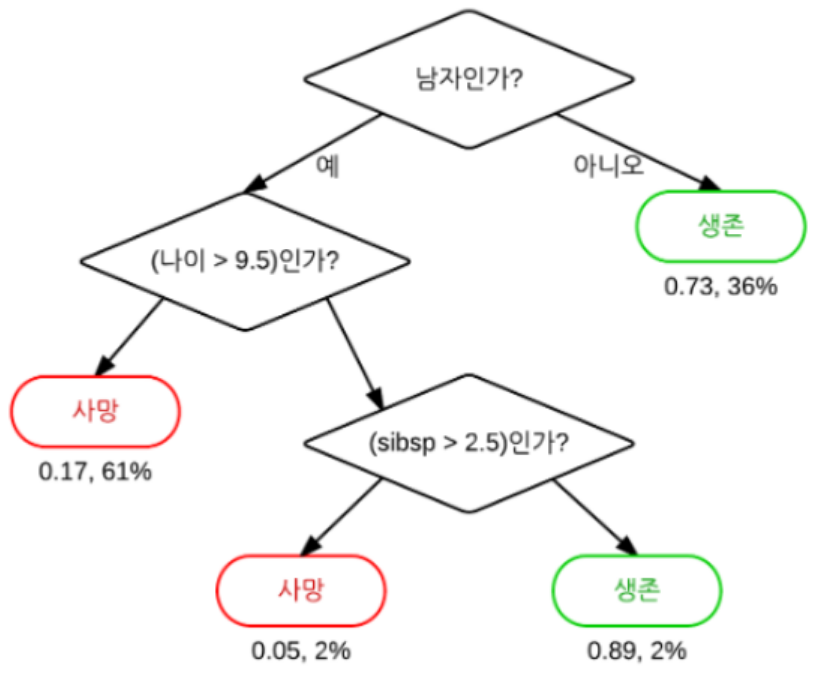

<br><br>
<h4>의사결정트리의 주요 구성 요소</h4>
&gt; 루트 노드(Root Node): <br>
    트리의 시작점<br>
    데이터셋 전체를 대표하는 특성으로 분할<br>
<br>
&gt; 내부 노드(Internal Nodes):<br>
    트리에서 분기를 나타내는 노드<br>
    각 내부 노드는 데이터를 분할하는 기준(특성 값의 조건)을 포함<br>
<br>
&gt; 리프 노드(Leaf Node):<br>
    트리의 마지막 노드로, 예측 결과가 나오는 지점<br>
    분류 문제에서는 리프 노드가 해당 클래스(class)를, 회귀 문제에서는 예측 값을 가짐<br>
<br>
&gt; 분기(Branches):<br>
    각 노드가 두 개 이상의 자식 노드로 분할되는 방식<br>
    분기 기준은 특성의 값에 따라 달라짐<br>
<br><br>


<h4>의사결정트리의 작동 방식</h4>
&gt; 지니 불순도(Gini Impurity):<br>
    분할된 데이터의 불순도를 측정<br>
    지니 불순도가 낮을수록 해당 분할이 데이터 분류에 유리하다고 판단<br>
    0~1 사이 값, 0에 가까울수록 불순도가 낮음 <br>


<h4>의사결정트리의 장점</h4>
&gt; 시각화가 용이:<br>
    트리 구조는 사람이 쉽게 이해할 수 있는 시각적인 형태를 제공<br>
    데이터가 어떻게 분할되는지 직관적으로 확인 가능<br>
<br>
&gt; 비선형 관계 처리 가능:<br>
    의사결정트리는 비선형 관계를 모델링하는 데 유리<br>
    선형 회귀 모델처럼 데이터를 직선으로 분할하지 않으며, 다양한 특성에 대해 복잡한 분할 가능<br>
    <br>
&gt; 특성 중요도 파악 가능:<br>
    모델이 어떤 특성을 기준으로 데이터를 분할하는지 알 수 있어, 데이터의 특성 중 어떤 것이 중요한지 파악 가능<br>
   <br> 
&gt; 전처리가 적음:<br>
    특성 간의 스케일 차이나 결측값에 크게 민감하지 않아서 데이터를 전처리할 때 복잡한 작업을 최소화할 수 있음<br>
<br>

&gt; 의사결정트리에서 사용하는 분할 기준은 **불순도(impurity)**를 최소화하는 방향으로 결정<p>

### iris 데이터셋

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [14]:
# 아이리스 데이터셋 로드
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [10]:
# 2. 데이터프레임 생성 (data와 feature_names 활용)
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 3. 타겟(레이블) 추가
df['target'] = iris.target
df['target_names'] = df['target'].apply(lambda x: iris.target_names[x])

# 결과 확인
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [ ]:
X = iris.data       # 독립변수 x가 여러개인 경우 대문자로, x가 하나면 소문자
y = iris.target

학습 데이터 정확도: 1.000
테스트 데이터 정확도: 1.000


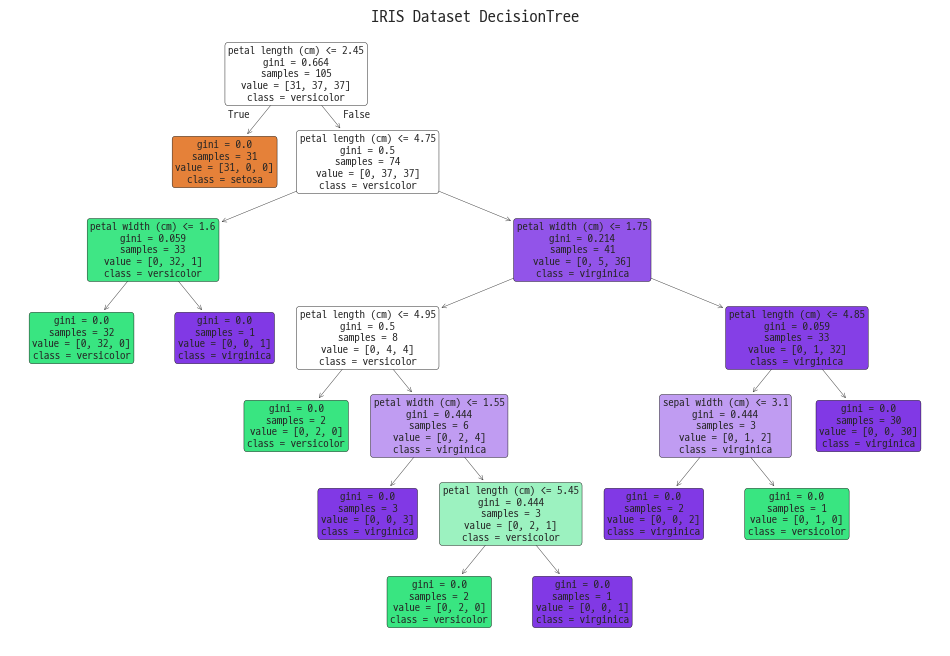

In [12]:
from sklearn.model_selection import train_test_split

# 데이터셋을 학습용과 테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 의사결정트리 모델 학습
clf = DecisionTreeClassifier(random_state=42)   ## 모델 생성
clf.fit(X_train, y_train)   ## 모델 훈련

# 모델 정확도 평가
train_score = clf.score(X_train, y_train)   ## 학습데이터 정확도
test_score = clf.score(X_test, y_test)      ## 테스트데이터 정확도 

print(f"학습 데이터 정확도: {train_score:.3f}")
print(f"테스트 데이터 정확도: {test_score:.3f}")

# 의사결정트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("IRIS Dataset DecisionTree")
plt.show()

In [15]:
# 새로운 값 (예: 4개의 특성 값으로 구성된 데이터)
new_data = np.array([[5.0, 3.4, 1.5, 0.2]])

# 예측
predicted_class = clf.predict(new_data)

# 예측 결과 출력
print(f"예측된 클래스: {iris.target_names[predicted_class][0]}")

예측된 클래스: setosa


In [16]:
new_data2 = np.array([
    [5.0, 3.4, 1.5, 0.2],  # 샘플 1
    [6.2, 3.0, 4.5, 1.5],  # 샘플 2
    [7.1, 3.0, 5.9, 2.1]   # 샘플 3
])

predicted_class2 = clf.predict(new_data2)
for pred in predicted_class2:
    print(iris.target_names[[pred]][0])

setosa
versicolor
virginica


1. 데이터셋 로드
2. 독립변수들과 종속변수 나누기
3. 분할 (훈련용, 테스트용)
4. DecisionTreeClassifier() 함수 이용하여 모델 생성, 학습
5. 평가
6. 시각화
7. 새로운 데이터로 예측

### wine 데이터셋

학습 데이터 정확도: 0.992
테스트 데이터 정확도: 0.963


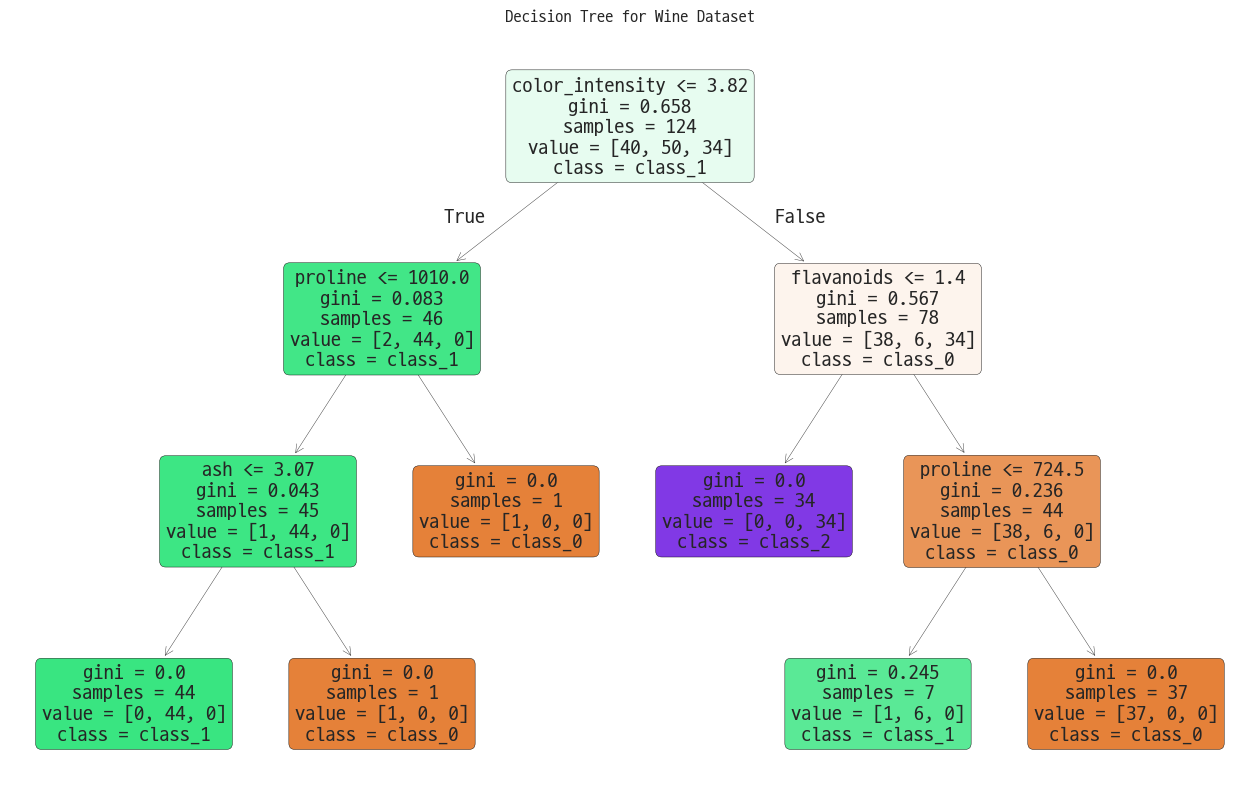

새로운 데이터 1: {'alcohol': 13.5, 'malic_acid': 2.1, 'ash': 2.5, 'alcalinity_of_ash': 15.0, 'magnesium': 95.0, 'total_phenols': 2.8, 'flavanoids': 3.1, 'nonflavanoid_phenols': 0.25, 'proanthocyanins': 1.9, 'color_intensity': 5.0, 'hue': 1.1, 'od280/od315_of_diluted_wines': 3.0, 'proline': 1100.0} -> 예측된 와인 클래스: class_0

새로운 데이터 2: {'alcohol': 12.0, 'malic_acid': 1.8, 'ash': 2.1, 'alcalinity_of_ash': 18.5, 'magnesium': 85.0, 'total_phenols': 2.2, 'flavanoids': 2.0, 'nonflavanoid_phenols': 0.35, 'proanthocyanins': 1.5, 'color_intensity': 3.2, 'hue': 0.9, 'od280/od315_of_diluted_wines': 2.5, 'proline': 800.0} -> 예측된 와인 클래스: class_1



In [18]:
# 와인 데이터셋 로드
from sklearn.datasets import load_wine
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# 데이터셋을 학습용과 테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 의사결정트리 모델 학습
clf = DecisionTreeClassifier(random_state=42, max_depth=3)  # 루트로드를 제외하고 3개층
clf.fit(X_train, y_train)

# 모델 평가
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"학습 데이터 정확도: {train_acc:.3f}")
print(f"테스트 데이터 정확도: {test_acc:.3f}")

# 의사결정트리 시각화
plt.figure(figsize=(16, 10))
plot_tree(
    clf,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Wine Dataset")
plt.show()


# 새로운 데이터로 예측
X_new = pd.DataFrame({
    'alcohol': [13.5, 12.0],
    'malic_acid': [2.1, 1.8],
    'ash': [2.5, 2.1],
    'alcalinity_of_ash': [15.0, 18.5],
    'magnesium': [95, 85],
    'total_phenols': [2.8, 2.2],
    'flavanoids': [3.1, 2.0],
    'nonflavanoid_phenols': [0.25, 0.35],
    'proanthocyanins': [1.9, 1.5],
    'color_intensity': [5.0, 3.2],
    'hue': [1.1, 0.9],
    'od280/od315_of_diluted_wines': [3.0, 2.5],
    'proline': [1100, 800]
})

# 예측 수행
y_pred = clf.predict(X_new)

# 결과 출력
for i, pred in enumerate(y_pred):
    print(f"새로운 데이터 {i+1}: {X_new.iloc[i].to_dict()} -> 예측된 와인 클래스: {wine.target_names[pred]}\n")

### 유방암 데이터셋

In [21]:
from sklearn.datasets import load_breast_cancer

# 1. 데이터 로드
cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [22]:
feature_names = [str(f) for f in cancer.feature_names]

X = pd.DataFrame(cancer.data, columns=feature_names)
y = cancer.target  # 0: malignant, 1: benign

학습 데이터 정확도: 0.995
테스트 데이터 정확도: 0.953


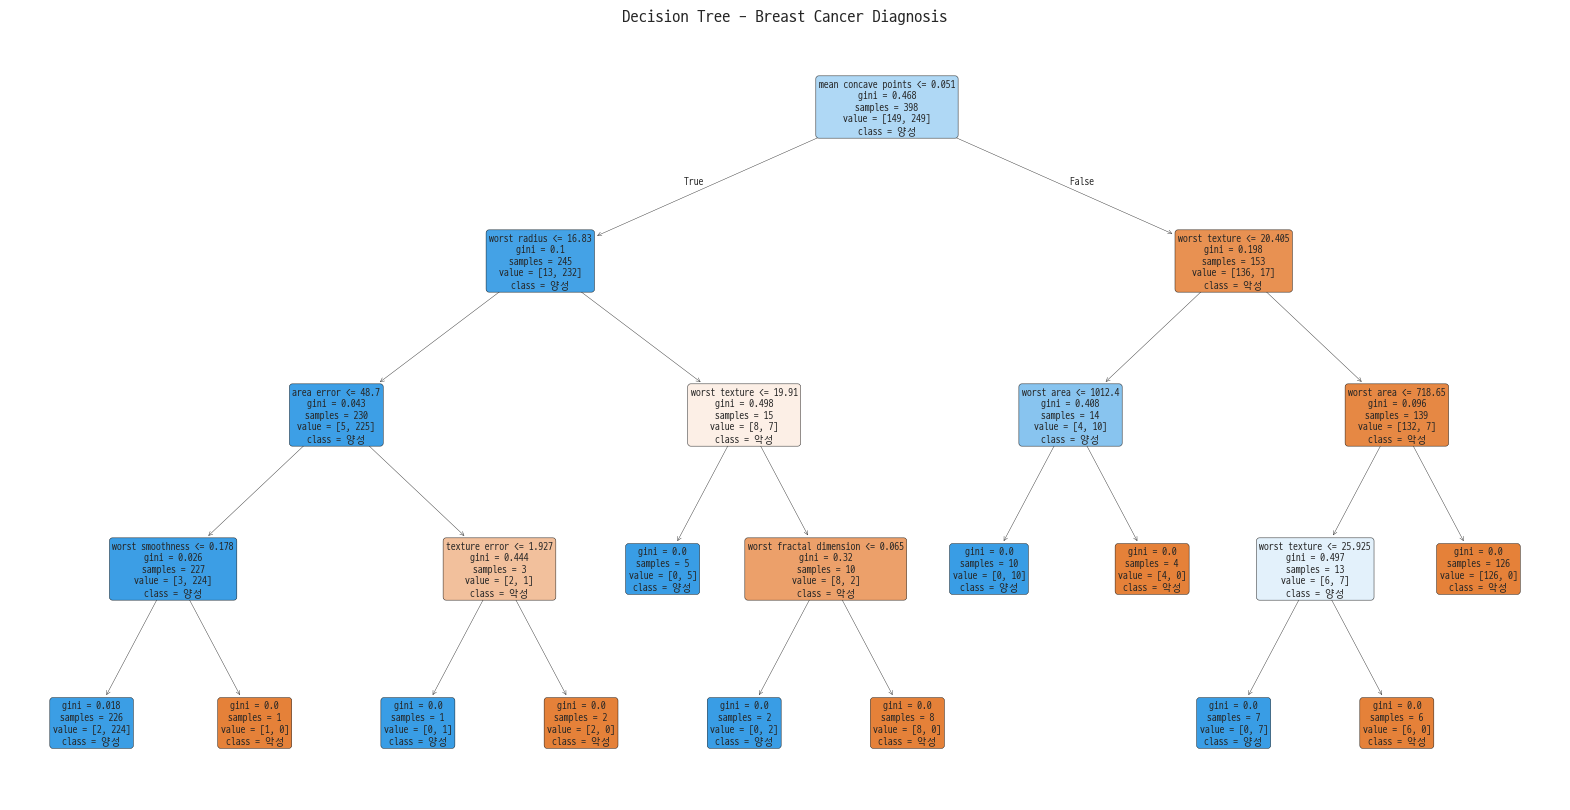

In [33]:
# 데이터셋을 학습용과 테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 의사결정트리 모델 학습
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
# clf = DecisionTreeClassifier() # max_depth=4를 지우면 지니계수가 0이 될 깨까지 계산한다
clf.fit(X_train, y_train)

# 모델 평가
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"학습 데이터 정확도: {train_acc:.3f}")
print(f"테스트 데이터 정확도: {test_acc:.3f}")

# 의사결정트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=cancer.feature_names,
    # class_names=cancer.target_names,
    class_names=['악성', '양성'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree - Breast Cancer Diagnosis")
plt.show()

In [35]:
# 6. 새로운 데이터 입력 (일부 특성만)
X_new = pd.DataFrame({
    # 이미 정의된 10개 mean 특성
    'mean radius': [14.5, 20.0],
    'mean texture': [20.0, 25.0],
    'mean perimeter': [95.0, 130.0],
    'mean area': [700.0, 1200.0],
    'mean smoothness': [0.1, 0.15],
    'mean compactness': [0.15, 0.2],
    'mean concavity': [0.05, 0.3],
    'mean concave points': [0.04, 0.2],
    'mean symmetry': [0.18, 0.3],
    'mean fractal dimension': [0.06, 0.1],

    'radius error': [0.5, 1.2],
    'texture error': [0.8, 1.5],
    'perimeter error': [2.0, 4.5],
    'area error': [40.0, 80.0],
    'smoothness error': [0.005, 0.01],
    'compactness error': [0.01, 0.02],
    'concavity error': [0.02, 0.05],
    'concave points error': [0.01, 0.03],
    'symmetry error': [0.02, 0.04],
    'fractal dimension error': [0.001, 0.002],

    'worst radius': [16.0, 25.0],
    'worst texture': [22.0, 30.0],
    'worst perimeter': [110.0, 160.0],
    'worst area': [800.0, 1500.0],
    'worst smoothness': [0.12, 0.18],
    'worst compactness': [0.2, 0.3],
    'worst concavity': [0.1, 0.4],
    'worst concave points': [0.08, 0.25],
    'worst symmetry': [0.25, 0.35],
    'worst fractal dimension': [0.07, 0.12]
})

# 7. 누락 특성 0으로 채우기 - 30개 중 위 데이터를 제외하고 나머지는 0.0으로
# for col in feature_names:
#     if col not in X_new.columns:
#         X_new[col] = 0.0

# 8. 열 이름 타입 맞추기 및 순서 재정렬
X_new.columns = X_new.columns.astype(str)
X_new = X_new[feature_names]

# 예측 수행
y_pred = clf.predict(X_new)

# 결과 출력
for i, pred in enumerate(y_pred):
    diagnosis = '악성' if pred == 0 else '양성'
    print(f"새로운 데이터 {i+1}: {X_new.iloc[i].to_dict()} -> 예측된 진단: {diagnosis}")

새로운 데이터 1: {'mean radius': 14.5, 'mean texture': 20.0, 'mean perimeter': 95.0, 'mean area': 700.0, 'mean smoothness': 0.1, 'mean compactness': 0.15, 'mean concavity': 0.05, 'mean concave points': 0.04, 'mean symmetry': 0.18, 'mean fractal dimension': 0.06, 'radius error': 0.5, 'texture error': 0.8, 'perimeter error': 2.0, 'area error': 40.0, 'smoothness error': 0.005, 'compactness error': 0.01, 'concavity error': 0.02, 'concave points error': 0.01, 'symmetry error': 0.02, 'fractal dimension error': 0.001, 'worst radius': 16.0, 'worst texture': 22.0, 'worst perimeter': 110.0, 'worst area': 800.0, 'worst smoothness': 0.12, 'worst compactness': 0.2, 'worst concavity': 0.1, 'worst concave points': 0.08, 'worst symmetry': 0.25, 'worst fractal dimension': 0.07} -> 예측된 진단: 양성
새로운 데이터 2: {'mean radius': 20.0, 'mean texture': 25.0, 'mean perimeter': 130.0, 'mean area': 1200.0, 'mean smoothness': 0.15, 'mean compactness': 0.2, 'mean concavity': 0.3, 'mean concave points': 0.2, 'mean symmetry': 0

In [ ]:
## 유방암 데이터셋을 데이터프레임 구조로 만들어서  csv 파일로 저장하기

# 데이터 로드
cancer = load_breast_cancer()

# DataFrame으로 변환
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# target 컬럼 추가
df['target'] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# CSV로 저장
df.to_csv('../../data/b_cancer.csv', index=False)


### 당뇨병 데이터셋

In [41]:
from sklearn.datasets import load_diabetes

In [44]:
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [ ]:
feature_names = [str(f) for f in diabetes.feature_names]
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

In [ ]:
# target이 분류형으로 된 데이터가 아니기 때문에 이를 그룹핑하여 새롭게 데이터를 만든다
y = np.where(diabetes.target >= diabetes.target.mean(), 1, 0) # 관계자라면 새분화하여 새롭게 만들 수 도 있다

학습 정확도: 0.799
테스트 정확도: 0.722


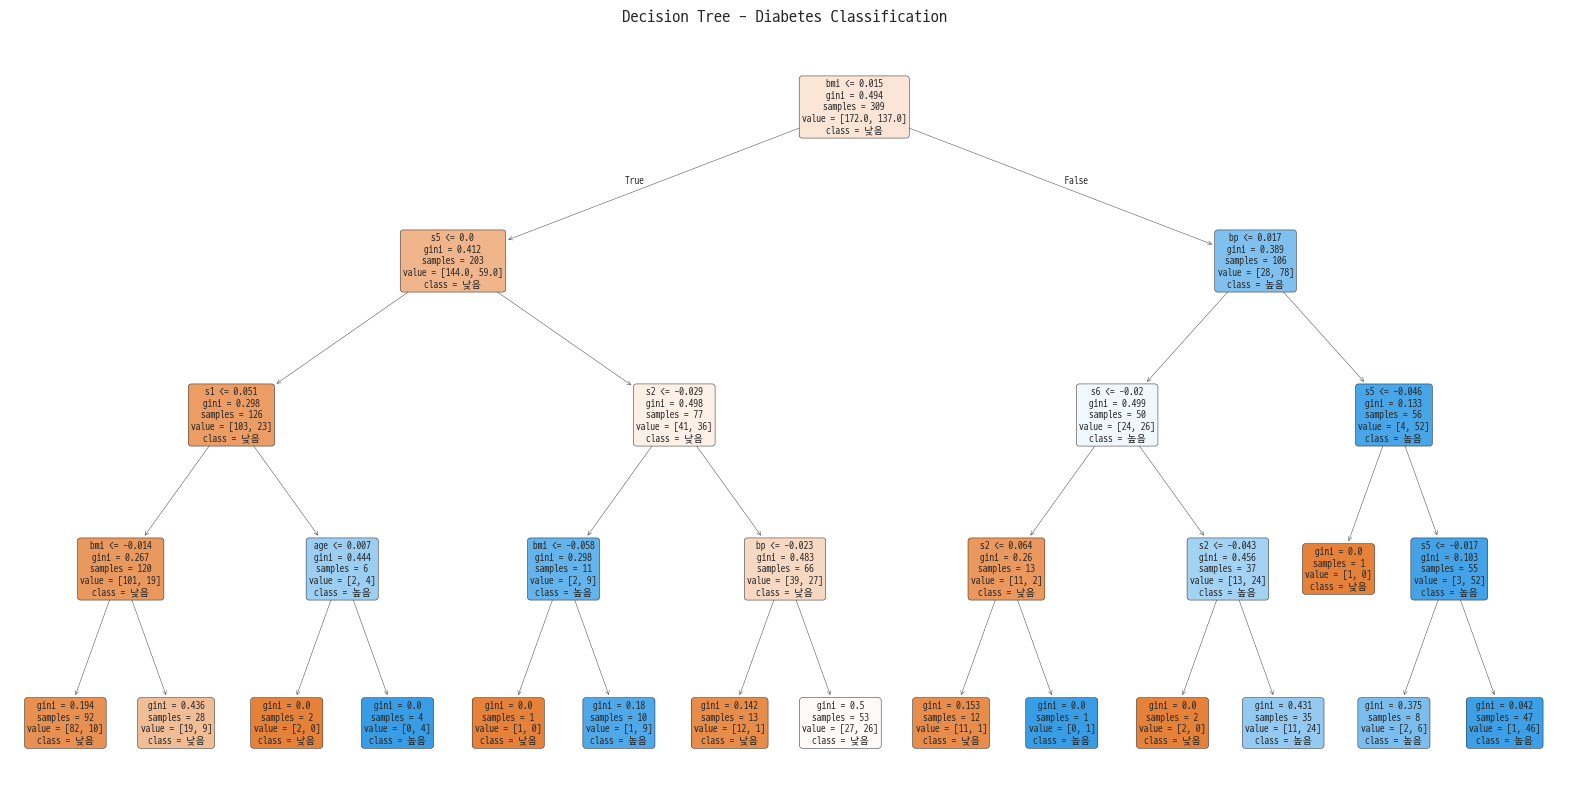

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

print(f"학습 정확도: {accuracy_score(y_train, clf.predict(X_train)):.3f}")
print(f"테스트 정확도: {accuracy_score(y_test, clf.predict(X_test)):.3f}")

plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=['낮음', '높음'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree - Diabetes Classification")
plt.show()